# Case study: How does a bike-share navigate speedy success?

## Ask
### How do annual members and casual riders use Cyclistic bikes dierently?


## Prepare
### The data used can be founf here: https://divvy-tripdata.s3.amazonaws.com/index.html
### We will use the data from april 2024 to march 2025

## Process
### We will use python on a jupyter notebook because it's easier to understand and it's great to compile only segments of the code

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os import listdir

In [190]:
# Extracting data from files
tripdata = pd.concat([pd.read_csv('./data/' + file) for file in listdir("./data/")])

In [82]:
# Exploring the data
tripdata.dtypes

rideable_type                  object
started_at             datetime64[ns]
ended_at               datetime64[ns]
start_station_name             object
start_station_id               object
end_station_name               object
end_station_id                 object
start_lat                     float64
start_lng                     float64
end_lat                       float64
end_lng                       float64
member_casual                  object
ride_length           timedelta64[ns]
day_of_week                     int64
dtype: object

In [189]:
tripdata.head(5)

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week
ride_id,,,,,,,,,,,,,,
743252713F32516B,classic_bike,2024-04-22 19:08:21,2024-04-22 19:12:56,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,41.878119,-87.643948,member,0 days 00:04:35,2
BE90D33D2240C614,electric_bike,2024-04-11 06:19:24,2024-04-11 06:22:21,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877722,-87.654959,41.878119,-87.643948,member,0 days 00:02:57,5
D47BBDDE7C40DD61,classic_bike,2024-04-20 11:13:13,2024-04-20 11:29:31,Sheridan Rd & Montrose Ave,TA1307000107,Ashland Ave & Belle Plaine Ave,13249,41.961670,-87.654640,41.956057,-87.668835,member,0 days 00:16:18,0
6684E760BF9EA9B5,classic_bike,2024-04-04 18:39:20,2024-04-04 18:43:06,Aberdeen St & Jackson Blvd,13157,Desplaines St & Jackson Blvd,15539,41.877726,-87.654787,41.878119,-87.643948,member,0 days 00:03:46,5
CA9EFC0D24C24A27,electric_bike,2024-04-19 19:30:20,2024-04-19 20:07:42,Sheridan Rd & Montrose Ave,TA1307000107,Stetson Ave & South Water St,TA1308000029,41.961613,-87.654615,41.886835,-87.622320,member,0 days 00:37:22,6


In [4]:
# Checking for null values
print(tripdata.isnull().values.any())

True


In [191]:
# Removing all rows with any null value
tripdata.dropna(inplace=True)
print(tripdata.isnull().values.any())

False


In [6]:
# Checking if all rows are unique
print(tripdata.ride_id.is_unique)

False


In [192]:
# Removing all duplicates
tripdata.drop_duplicates(subset=['ride_id'], keep=False, inplace=True)
print(tripdata.ride_id.is_unique)

True


In [193]:
# Index data by ride_id
tripdata.set_index('ride_id', inplace=True)

## Analyze
### Now we add some calculated columns and create some new dataframes to understand better the data.

In [194]:
# Changing dates to datetime for easier manipulation
tripdata['started_at'] = pd.to_datetime(tripdata.started_at, format='ISO8601')
tripdata['ended_at'] = pd.to_datetime(tripdata.ended_at, format='ISO8601')

In [197]:
# Checking the length of each ride
tripdata['ride_length'] = tripdata.ended_at - tripdata.started_at

In [200]:
print('Longest ride:', tripdata.ride_length.max())
print('Shortest ride: ', tripdata.ride_length.min())
print('Avarage ride: ', tripdata.ride_length.mean())

Longest ride: 1 days 00:58:26.094000
Shortest ride:  0 days 00:00:00
Avarage ride:  0 days 00:16:35.006921900


In [199]:
# Remove rides with negative duration
tripdata.drop(tripdata[tripdata.ride_length < pd.Timedelta(0)].index, inplace=True)

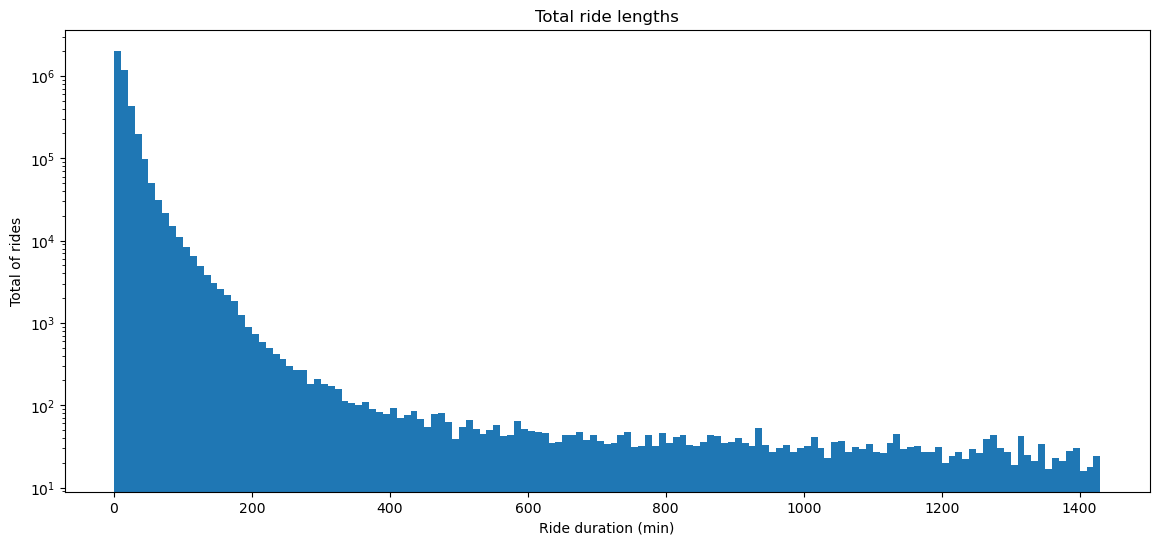

In [223]:
plt.figure(figsize=(14,6))
plt.hist(tripdata.ride_length.dt.seconds.values/60, log=True, bins=range(0, round(tripdata.ride_length.dt.seconds.values.max()/60), 10))
plt.xlabel('Ride duration (min)')
plt.ylabel('Total of rides')
plt.title('Total ride lengths')
plt.show()

### Here we notice that most of the rides have short duration

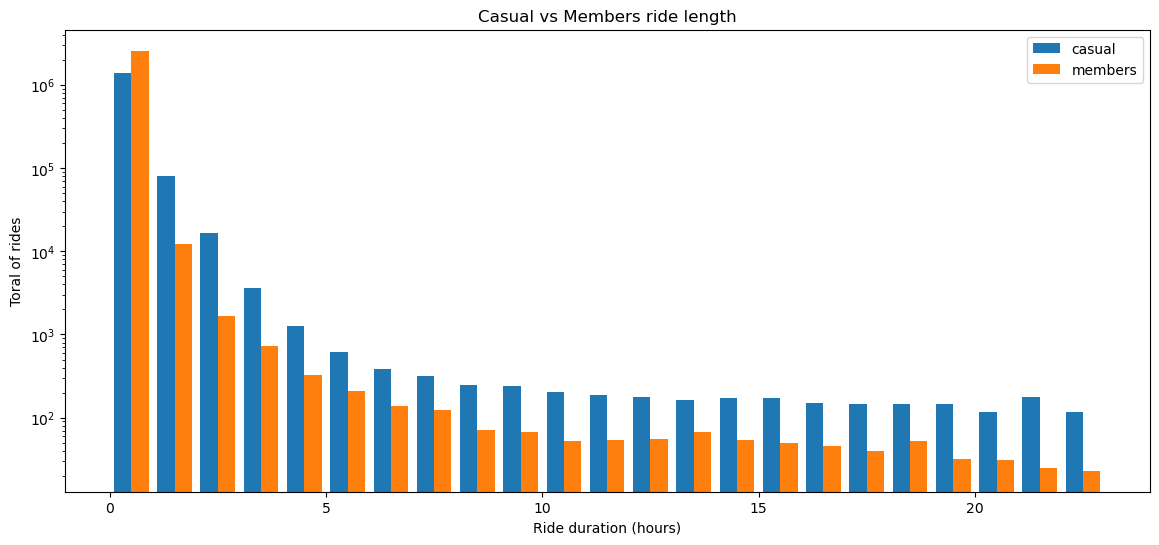

In [202]:
casual_rides = tripdata[tripdata.member_casual == 'casual'].ride_length.dt.seconds.values/3600
member_rides = tripdata[tripdata.member_casual == 'member'].ride_length.dt.seconds.values/3600

plt.hist([casual_rides, member_rides], log=True, label=['casual', 'members'],
         bins=range(0, round(tripdata.ride_length.dt.seconds.values.max()/3600), 1))
plt.xlabel('Ride duration (hours)')
plt.ylabel('Total of rides')
plt.title('Casual vs Members ride length')
plt.legend(['casual', 'members'])
plt.show()

### It's interesting that member riders do shorter rides than casual

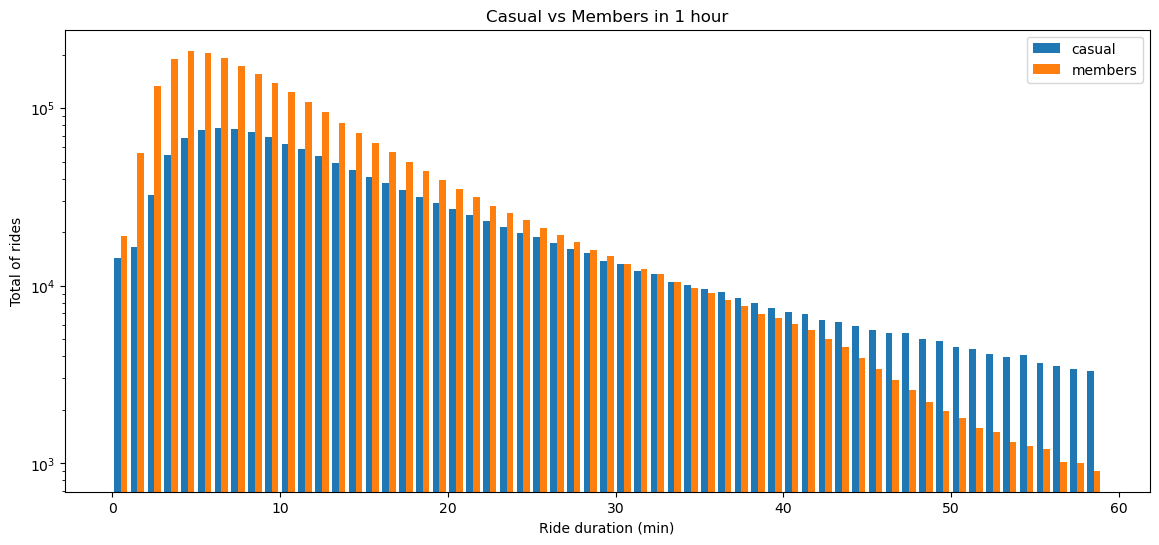

In [256]:
short_trips = tripdata[tripdata.ride_length < pd.Timedelta(1, 'h')]
casual_rides = short_trips[short_trips.member_casual == 'casual'].ride_length.dt.seconds.values/60
member_rides = short_trips[short_trips.member_casual == 'member'].ride_length.dt.seconds.values/60

plt.figure(figsize=(14,6))
plt.hist([casual_rides, member_rides], log=True, label=['casual', 'members'], bins=range(0, 60, 1))
plt.xlabel('Ride duration (min)')
plt.ylabel('Total of rides')
plt.title('Casual vs Members in 1 hour')
plt.legend(['casual', 'members'])
plt.show()

### For some reason member riders tend to do more short rides than casual people, less than half an hour

In [204]:
# Checking the day of the week that each ride started using the bike
# 0=monday - 6=sunday
tripdata['day_of_week'] = tripdata.started_at.dt.dayofweek

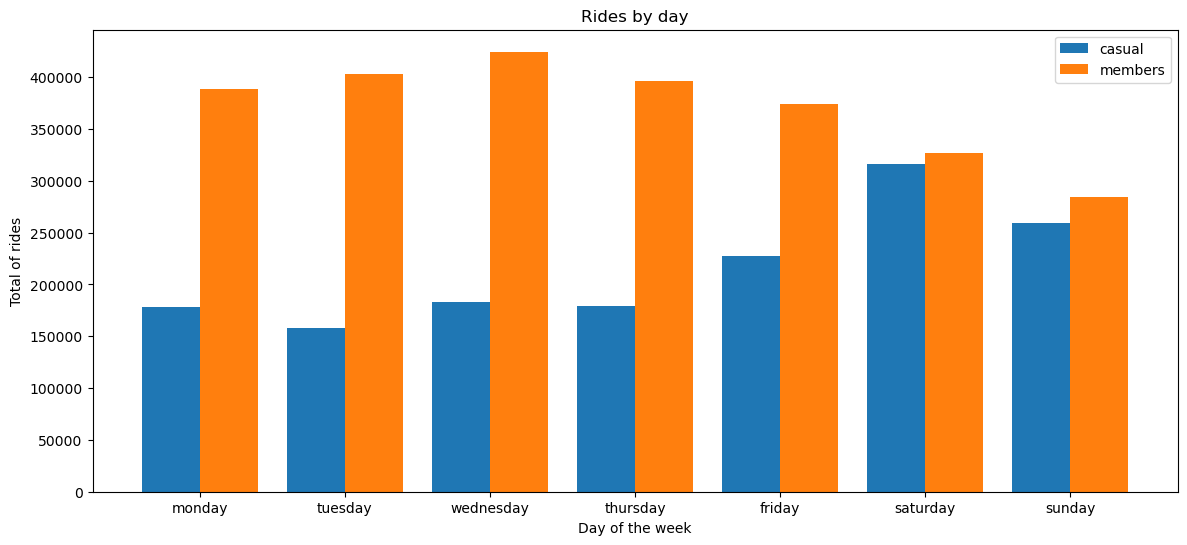

In [254]:
casual_rides = tripdata[tripdata.member_casual == 'casual'].groupby('day_of_week').count().ended_at.values
member_rides = tripdata[tripdata.member_casual == 'member'].groupby('day_of_week').count().ended_at.values
w, x = 0.4, np.arange(7)

plt.figure(figsize=(14,6))
plt.bar(x - w/2, casual_rides, 0.4, label='casual')
plt.bar(x + w/2, member_rides, 0.4, label='members')
plt.xticks(range(7), ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'])
plt.xlabel('Day of the week')
plt.ylabel('Total of rides')
plt.title('Rides by day')
plt.legend()
plt.show()

### As we can see, in labor days member riders use the service more often, this migth be because they use the bikes to go to work, instead casual riders probably use the bikes more on weekends for fun

In [255]:
print('Total rides in the 12 months: ', len(tripdata))

Total rides in the 12 months:  4099859
